In [1]:
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import numpy as np
import optuna
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from ray.tune.integration.keras import TuneReportCallback
from ray.tune import TuneConfig
from ray.tune import Tuner, TuneConfig
from ray.air.config import RunConfig
from ray.tune.progress_reporter import CLIReporter
import time,psutil
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from optuna.integration import TFKerasPruningCallback



c:\Users\ASUS ZENBOOK\inz\.venv\Scripts\python.exe


c:\Users\ASUS ZENBOOK\inz\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-20 00:36:48,923	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-20 00:36:49,262	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-20 00:36:49,664	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:

# Parametry
N = 10000
rng = np.random.default_rng(42)

# Klasy: 0 - karpiowy, 1 - liniowy, 2 - pstrągowy
classes = rng.choice([0, 1, 2], size=N, p=[0.4, 0.35, 0.25])

# Cechy środowiskowe i biologiczne
temperatura = np.select([classes==0, classes==1, classes==2],
                        [rng.normal(20, 3, N), rng.normal(18, 3, N), rng.normal(15, 3, N)])
ph = np.select([classes==0, classes==1, classes==2],
               [rng.normal(7.3, 0.3, N), rng.normal(7.1, 0.3, N), rng.normal(6.9, 0.3, N)])
tlen = np.select([classes==0, classes==1, classes==2],
                 [rng.normal(6.8, 0.6, N), rng.normal(7.2, 0.6, N), rng.normal(7.8, 0.6, N)])
azotany = np.select([classes==0, classes==1, classes==2],
                    [rng.normal(2.8, 0.9, N), rng.normal(2.6, 0.9, N), rng.normal(2.0, 0.9, N)])
fosforany = np.select([classes==0, classes==1, classes==2],
                      [rng.normal(0.55, 0.2, N), rng.normal(0.5, 0.2, N), rng.normal(0.45, 0.2, N)])
przezroczystosc = np.select([classes==0, classes==1, classes==2],
                            [rng.normal(1.5, 0.4, N), rng.normal(1.6, 0.4, N), rng.normal(1.8, 0.4, N)])
gleba = np.select([classes==0, classes==1, classes==2],
                  [rng.normal(5.0, 1.2, N), rng.normal(4.8, 1.2, N), rng.normal(5.3, 1.2, N)])
powierzchnia = np.select([classes==0, classes==1, classes==2],
                         [rng.normal(2.2, 0.5, N), rng.normal(2.0, 0.5, N), rng.normal(2.4, 0.5, N)])
glebokosc = np.select([classes==0, classes==1, classes==2],
                      [rng.normal(1.8, 0.4, N), rng.normal(2.0, 0.4, N), rng.normal(2.3, 0.4, N)])
roslinnosc = np.select([classes==0, classes==1, classes==2],
                       [rng.normal(0.7, 0.2, N), rng.normal(0.8, 0.2, N), rng.normal(0.6, 0.2, N)])
przeplyw = np.select([classes==0, classes==1, classes==2],
                     [rng.normal(0.35, 0.1, N), rng.normal(0.4, 0.1, N), rng.normal(0.5, 0.1, N)])
srednia_waga_ryb = np.select([classes==0, classes==1, classes==2],
                             [rng.normal(1.0, 0.3, N), rng.normal(0.8, 0.3, N), rng.normal(0.6, 0.3, N)])

# DataFrame
df = pd.DataFrame({
    "temperatura_wody": temperatura,
    "pH": ph,
    "tlen": tlen,
    "azotany": azotany,
    "fosforany": fosforany,
    "przezroczystość": przezroczystosc,
    "gleba": gleba,
    "powierzchnia_stawu": powierzchnia,
    "głębokość": glebokosc,
    "roślinność": roslinnosc,
    "przepływ": przeplyw,
    "średnia_waga_ryb": srednia_waga_ryb,
    "typ_stawu": classes
})

df.head()


,temperatura_wody,pH,tlen,azotany,fosforany,przezroczystość,gleba,powierzchnia_stawu,głębokość,roślinność,przepływ,średnia_waga_ryb,typ_stawu
0,13.130020,7.310568,7.967733,0.908961,0.485740,1.533415,7.142764,2.445784,1.104145,1.006620,0.661675,0.405642,2
1,19.059878,7.889500,7.701760,4.252272,0.612896,1.742016,7.346519,2.897605,1.434205,1.242355,0.504070,0.902930,1
2,10.897911,7.196176,7.226915,1.166437,0.717741,1.742751,5.638979,1.826318,1.963133,0.668712,0.494104,0.484903,2
3,23.206871,6.824368,7.372442,2.893207,0.601915,1.255983,4.382673,1.525754,1.931104,0.579046,0.399120,0.934168,1
4,21.563828,7.328966,6.684946,1.986958,0.407372,1.615872,4.935692,2.614010,1.198554,0.478093,0.221704,0.939020,0


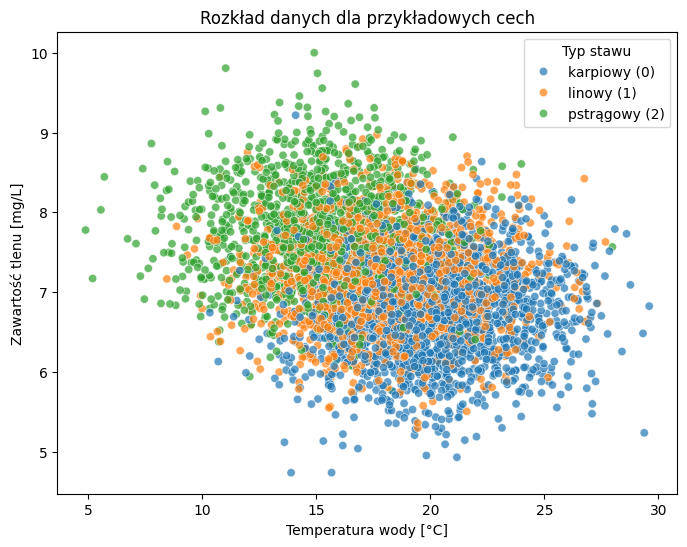

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_df = df.sample(5000, random_state=42)

palette_map = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=sample_df,
    x="temperatura_wody",
    y="tlen",
    hue="typ_stawu",
    palette=palette_map,
    alpha=0.7
)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["karpiowy (0)", "linowy (1)", "pstrągowy (2)"], title="Typ stawu")

plt.title("Rozkład danych dla przykładowych cech")
plt.xlabel("Temperatura wody [°C]")
plt.ylabel("Zawartość tlenu [mg/L]")
plt.show()

In [4]:
#zaokrąglenie dla czytelności
df = df.round(3)
df.head()

,temperatura_wody,pH,tlen,azotany,fosforany,przezroczystość,gleba,powierzchnia_stawu,głębokość,roślinność,przepływ,średnia_waga_ryb,typ_stawu
0,13.130,7.311,7.968,0.909,0.486,1.533,7.143,2.446,1.104,1.007,0.662,0.406,2
1,19.060,7.890,7.702,4.252,0.613,1.742,7.347,2.898,1.434,1.242,0.504,0.903,1
2,10.898,7.196,7.227,1.166,0.718,1.743,5.639,1.826,1.963,0.669,0.494,0.485,2
3,23.207,6.824,7.372,2.893,0.602,1.256,4.383,1.526,1.931,0.579,0.399,0.934,1
4,21.564,7.329,6.685,1.987,0.407,1.616,4.936,2.614,1.199,0.478,0.222,0.939,0


In [5]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperatura_wody    10000 non-null  float64
 1   pH                  10000 non-null  float64
 2   tlen                10000 non-null  float64
 3   azotany             10000 non-null  float64
 4   fosforany           10000 non-null  float64
 5   przezroczystość     10000 non-null  float64
 6   gleba               10000 non-null  float64
 7   powierzchnia_stawu  10000 non-null  float64
 8   głębokość           10000 non-null  float64
 9   roślinność          10000 non-null  float64
 10  przepływ            10000 non-null  float64
 11  średnia_waga_ryb    10000 non-null  float64
 12  typ_stawu           10000 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 1015.8 KB
None


In [6]:
print(df.describe().T)

                      count       mean       std    min       25%      50%  \
temperatura_wody    10000.0  18.097343  3.600664  4.744  15.65975  18.1720   
pH                  10000.0   7.129347  0.336918  5.844   6.90100   7.1280   
tlen                10000.0   7.181230  0.723651  4.734   6.68375   7.1570   
azotany             10000.0   2.542171  0.959660 -1.312   1.87900   2.5480   
fosforany           10000.0   0.509748  0.204622 -0.255   0.37300   0.5140   
przezroczystość     10000.0   1.612321  0.419023  0.155   1.32500   1.6080   
gleba               10000.0   5.004868  1.208973 -0.914   4.20400   5.0260   
powierzchnia_stawu  10000.0   2.183831  0.523507  0.171   1.82575   2.1840   
głębokość           10000.0   1.996999  0.448564  0.266   1.68900   1.9870   
roślinność          10000.0   0.709666  0.211412 -0.071   0.56700   0.7070   
przepływ            10000.0   0.403596  0.115413  0.016   0.32475   0.4000   
średnia_waga_ryb    10000.0   0.828193  0.338294 -0.335   0.5960

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Podział 70/30: trening/test
X = df.drop(columns=["typ_stawu"])
y = df["typ_stawu"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# walidacja wydzielona z treningu  20% z treningu)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

print("Treningowe:", X_train.shape)
print("Walidacyjne:", X_val.shape)
print("Testowe:", X_test.shape)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_val_scaled   = scaler.transform(X_val)
x_test_scaled  = scaler.transform(X_test)


Treningowe: (5600, 12)
Walidacyjne: (1400, 12)
Testowe: (3000, 12)


## Model Bazowy Autoenkoder

In [ ]:
input_dim = x_train_scaled.shape[1]
num_classes = len(np.unique(y_train))
encoding_dim = 6  

def build_autoencoder():
    input_layer = layers.Input(shape=(input_dim,))
    
    # ENCODER
    encoded = layers.Dense(32, activation='relu')(input_layer)
    encoded = layers.Dense(16, activation='relu')(encoded)
    bottleneck = layers.Dense(encoding_dim, activation='relu', name="bottleneck")(encoded)
    
    # DECODER
    decoded = layers.Dense(16, activation='relu')(bottleneck)
    decoded = layers.Dense(32, activation='relu')(decoded)
    output_layer = layers.Dense(input_dim, activation='linear', name='reconstruction')(decoded)
    
    # KLASYFIKATOR
    clas =  layers.Dense(16, activation='relu')(bottleneck)
    class_out = layers.Dense(num_classes, activation='softmax', name='class_output')(clas)
    
    # MODEL
    autoencoder = keras.Model(inputs=input_layer, outputs=[class_out, output_layer])
    optimizer = keras.optimizers.Adam(learning_rate=0.005)

    autoencoder.compile(
        optimizer = optimizer,


        loss={ 
            'class_output': 'sparse_categorical_crossentropy', 
            'reconstruction': 'mse'
        },
        loss_weights={
            'class_output': 1.0,
            'reconstruction': 0.5 
        },
        metrics={
            'class_output': 'accuracy'
        }
    )
    
    return autoencoder

#Inicjalizacja modelu
autoencoder = build_autoencoder()

start = time.perf_counter()
process = psutil.Process()

history = autoencoder.fit(
    x_train_scaled, 
    {'class_output':y_train #etykiety stawu
    , 'reconstruction':x_train_scaled},
    validation_data=(x_val_scaled, {'class_output': y_val, 'reconstruction': x_val_scaled}),
    epochs=50,
    batch_size=64,
    shuffle=True,
    verbose=1
)

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024*1024)
print(f"Czas uczenia: {elapsed:.2f}s")
print(f"Zużycie pamięci: {mem_used:.2f} MB")


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - class_output_accuracy: 0.7166 - class_output_loss: 0.7320 - loss: 1.1413 - reconstruction_loss: 0.8168 - val_class_output_accuracy: 0.7821 - val_class_output_loss: 0.5053 - val_loss: 0.8578 - val_reconstruction_loss: 0.7062
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - class_output_accuracy: 0.7868 - class_output_loss: 0.4865 - loss: 0.8224 - reconstruction_loss: 0.6699 - val_class_output_accuracy: 0.7929 - val_class_output_loss: 0.4744 - val_loss: 0.7896 - val_reconstruction_loss: 0.6314
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - class_output_accuracy: 0.7977 - class_output_loss: 0.4642 - loss: 0.7647 - reconstruction_loss: 0.6001 - val_class_output_accuracy: 0.7829 - val_class_output_loss: 0.4664 - val_loss: 0.7504 - val_reconstruction_loss: 0.5690
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - class_output_accuracy: 0.7982 - class_output_loss: 0.4627 - loss: 0.7392 - reconstruction_loss: 0.5519 - val_class_outpu

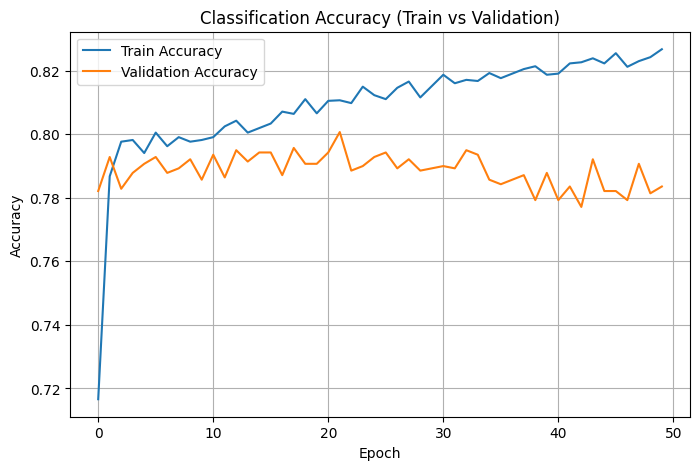

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history['class_output_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_class_output_accuracy'], label='Validation Accuracy')
plt.title('Classification Accuracy (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
_, x_test_pred = autoencoder.predict(x_test_scaled)
# MSE dla każdej próbki testowej
recon_errors = np.mean((x_test_scaled - x_test_pred) ** 2, axis=1)
recon_errors[:10]


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([0.59226039, 0.8267154 , 0.44184339, 0.14776743, 0.20378347,
       0.45778171, 0.40940271, 0.4417512 , 0.4872996 , 0.34200832])

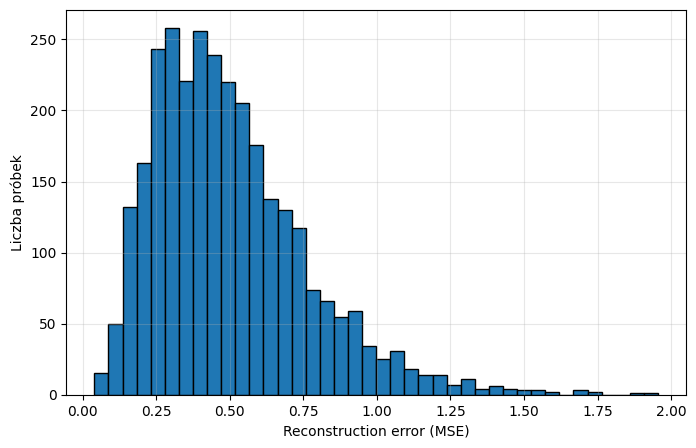

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(recon_errors, bins=40, edgecolor='black')
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Liczba próbek")
plt.grid(True, alpha=0.3)
plt.show()


## Keras Tuner : Random Search

In [15]:
input_dim = x_train_scaled.shape[1]
num_classes = len(np.unique(y_train))
def build_autoencoder_model(hp):
    #Przedział wyborów HP
    hp_units_1 = hp.Int('units_1', min_value=16, max_value=128, step=16)
    hp_units_2 = hp.Int('units_2', min_value=8, max_value=64, step=8)
    hp_encoded = hp.Int('encoding_dim', min_value=4, max_value=12, step=2)
    hp_learning_rate = hp.Choice('learning_rate', values=[0.001, 0.003, 0.005, 0.01])
    input_layer = layers.Input(shape=(input_dim,))
    hp_class_units = hp.Int('class_units', min_value=8, max_value=64, step=8)


    #Encoder
    encoded = layers.Dense(hp_units_1, activation='relu')(input_layer)
    encoded = layers.Dense(hp_units_2, activation='relu')(encoded)
    bottleneck = layers.Dense(hp_encoded, activation='relu', name='bottleneck')(encoded)

    #Decoder
    decoded = layers.Dense(hp_units_2, activation='relu')(bottleneck)
    decoded = layers.Dense(hp_units_1, activation='relu')(decoded)
    output_layer = layers.Dense(input_dim, activation='linear', name='reconstruction')(decoded)

    #Klasyfikator
    clas = layers.Dense(hp_class_units, activation='relu')(bottleneck)
    class_out = layers.Dense(num_classes, activation='softmax', name='class_output')(clas)

    #Model
    autoencoder = keras.Model(inputs=input_layer, outputs=[class_out, output_layer])
    optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate)
    
    autoencoder.compile(
        optimizer=optimizer,
        loss={
            'class_output': 'sparse_categorical_crossentropy',
            'reconstruction': 'mse'
        },
        loss_weights={
            'class_output':1.0, 
            'reconstruction':0.5 
        },
        metrics={
            'class_output': SparseCategoricalAccuracy(name='accuracy')
        }
    )

    return autoencoder


callback = keras.callbacks.EarlyStopping(
    monitor='val_class_output_accuracy',  
    patience=10,
    mode='max',
    restore_best_weights=True
)

start = time.perf_counter()
process = psutil.Process()

tuner = kt.RandomSearch(
    build_autoencoder_model,
    objective=kt.Objective('val_class_output_accuracy', direction='max'),
    max_trials=20,
    executions_per_trial = 1,
    directory="C:\\Users\\ASUS ZENBOOK\\Desktop",
    project_name = "random_search_autoencoder_class10"
)

tuner.search(
    x_train_scaled, 
    {'class_output': y_train, 'reconstruction': x_train_scaled},
    validation_data=(
        x_val_scaled,
        {'class_output': y_val, 'reconstruction': x_val_scaled}
    ),
    epochs=50,
    callbacks=[callback],
    batch_size=64,
    verbose=1
)

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024*1024)
print(f"\nCzas wyszukiwania: {round(elapsed,2)}")
print(f"\nZużycie pamięci: {round(mem_used,2)}")

#najlepsze hiperparametry
best_hp_rs = tuner.get_best_hyperparameters(1)[0]
best_model_rs = tuner.hypermodel.build(best_hp_rs)

print(f"""
Najlepsze hiperparametry:
- units_1: {best_hp_rs.get('units_1')}
- units_2: {best_hp_rs.get('units_2')}
- encoding_dim: {best_hp_rs.get('encoding_dim')}
- learning_rate: {best_hp_rs.get('learning_rate')}
- class units : {best_hp_rs.get('class_units')}
""")

history_best_rs = best_model_rs.fit(
    x_train_scaled,
    {'class_output': y_train, 'reconstruction': x_train_scaled},
    validation_data=(
        x_val_scaled,
        {'class_output': y_val, 'reconstruction': x_val_scaled}
    ),
    epochs=50,
    batch_size=64,
    callbacks=[callback],
    verbose=1
)

eval_results_rs = best_model_rs.evaluate(
    x_test_scaled,
    {'class_output': y_test, 'reconstruction': x_test_scaled},
    verbose=0,
    return_dict=True
)

print("\nWyniki na zbiorze testowym (surowe):")
print(eval_results_rs)

print("\nŁadnie sformatowane:")
print(f"total_loss:            {eval_results_rs['loss']:.4f}")
print(f"class_output_loss:     {eval_results_rs['class_output_loss']:.4f}")
print(f"reconstruction_loss:   {eval_results_rs['reconstruction_loss']:.4f}")
print(f"class_output_accuracy: {eval_results_rs['class_output_accuracy']:.4f}")



Trial 20 Complete [00h 00m 08s]
val_class_output_accuracy: 0.793571412563324

Best val_class_output_accuracy So Far: 0.8042857050895691
Total elapsed time: 00h 02m 09s

Czas wyszukiwania: 129.1

Zużycie pamięci: 1091.73

Najlepsze hiperparametry:
- units_1: 16
- units_2: 32
- encoding_dim: 4
- learning_rate: 0.003
- class units : 8

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - class_output_accuracy: 0.6320 - class_output_loss: 0.8188 - loss: 1.2436 - reconstruction_loss: 0.8455 - val_class_output_accuracy: 0.7543 - val_class_output_loss: 0.5858 - val_loss: 0.9494 - val_reconstruction_loss: 0.7281
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - class_output_accuracy: 0.7777 - class_output_loss: 0.5335 - loss: 0.8847 - reconstruction_loss: 0.7006 - val_class_output_accuracy: 0.7900 - val_class_output_loss: 0.4978 - val_loss: 0.8351 - val_reconstruction_loss: 0.6753
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - class_output_accuracy: 0.7891 - class_output_loss: 0.4818 - l

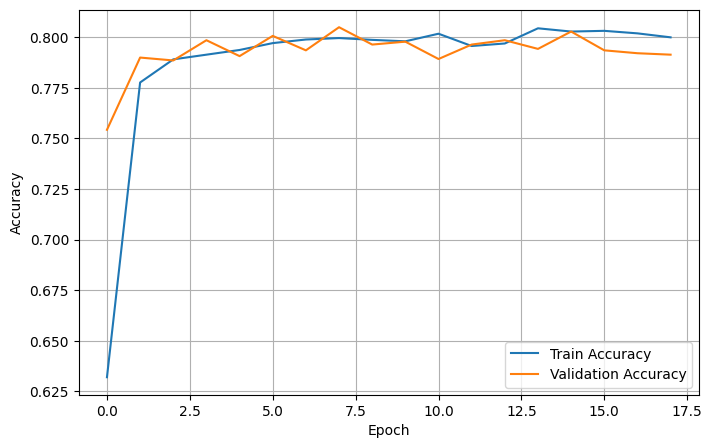

In [37]:
plt.figure(figsize=(8,5))
plt.plot(history_best_rs.history['class_output_accuracy'], label='Train Accuracy')
plt.plot(history_best_rs.history['val_class_output_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[0.41560563 0.8468264  0.5417215  0.62320897 0.49667211 0.95967165
 0.78096174 1.02737805 0.88529627 0.46584741]


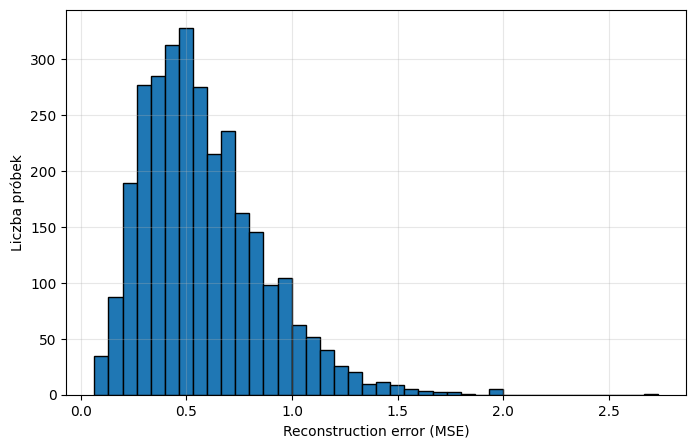

In [38]:
# Predykcja rekonstrukcji (wyjście drugie)
class_pred, x_test_pred = best_model_rs.predict(x_test_scaled)

# Błąd rekonstrukcji MSE dla każdej próbki
recon_errors_rs = np.mean((x_test_scaled - x_test_pred)**2, axis=1)
print(recon_errors_rs[:10])

plt.figure(figsize=(8,5))
plt.hist(recon_errors_rs, bins=40, edgecolor='black')
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Liczba próbek")
plt.grid(True, alpha=0.3)
plt.show()


## Hyperband

In [18]:
input_dim = x_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

def build_autoencoder_model(hp):
    #Przedział wyborów HP
    hp_units_1 = hp.Int('units_1', min_value=16, max_value=128, step=16)
    hp_units_2 = hp.Int('units_2', min_value=8, max_value=64, step=8)
    hp_encoded = hp.Int('encoding_dim', min_value=4, max_value=12, step=2)
    hp_learning_rate = hp.Choice('learning_rate', values=[0.001, 0.003, 0.005, 0.01])
    input_layer = layers.Input(shape=(input_dim,))
    hp_class_units = hp.Int('class_units', min_value=8, max_value=64, step=8)

    #Encoder
    encoded = layers.Dense(hp_units_1, activation='relu')(input_layer)
    encoded = layers.Dense(hp_units_2, activation='relu')(encoded)
    bottleneck = layers.Dense(hp_encoded, activation='relu', name='bottleneck')(encoded)

    #Decoder
    decoded = layers.Dense(hp_units_2, activation='relu')(bottleneck)
    decoded = layers.Dense(hp_units_1, activation='relu')(decoded)
    output_layer = layers.Dense(input_dim, activation='linear', name='reconstruction')(decoded)

    #Klasyfikator
    clas = layers.Dense(hp_class_units, activation='relu')(bottleneck)
    class_out = layers.Dense(num_classes, activation='softmax', name='class_output')(clas)

    #Model
    autoencoder = keras.Model(inputs=input_layer, outputs=[class_out, output_layer])
    optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate)

    autoencoder.compile(
        optimizer=optimizer,
        loss={
            'class_output': 'sparse_categorical_crossentropy',
            'reconstruction': 'mse'
        },
        loss_weights={
            'class_output': 1.0,
            'reconstruction': 0.5
        },
        metrics={
            'class_output': SparseCategoricalAccuracy(name='accuracy')
        }
    )

    return autoencoder


callback = keras.callbacks.EarlyStopping(
    monitor='val_class_output_accuracy',
    patience=10,
    mode='max',
    restore_best_weights=True
)

start = time.perf_counter()
process = psutil.Process()

tuner = kt.Hyperband(
    hypermodel=build_autoencoder_model,
    objective=kt.Objective("val_class_output_accuracy", direction="max"),
    max_epochs=50,
    factor=3,
    directory="C:\\Users\\ASUS ZENBOOK\\Desktop",
    project_name="hyperband_autoencoder_class3.3"
)

tuner.search(
    x_train_scaled,
    {'class_output': y_train, 'reconstruction': x_train_scaled},
    validation_data=(
        x_val_scaled,
        {'class_output': y_val, 'reconstruction': x_val_scaled}
    ),
    epochs=50,
    callbacks=[callback],
    batch_size=64,
    verbose=1
)

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024 * 1024)
print(f"Czas szukania: {round(elapsed, 2)}s")
print(f"Zużycie pamięci: {round(mem_used, 2)}MB")

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model_hyperband = tuner.hypermodel.build(best_hps)

print(f"""
Najlepsze hiperparametry:
- units_1: {best_hps.get('units_1')}
- units_2: {best_hps.get('units_2')}
- encoding_dim: {best_hps.get('encoding_dim')}
- learning_rate: {best_hps.get('learning_rate')}
- calss_units: {best_hps.get('class_units')}
""")

history_best_hyperbadnd = best_model_hyperband.fit(
    x_train_scaled,
    {'class_output': y_train, 'reconstruction': x_train_scaled},
    validation_data=(
        x_val_scaled,
        {'class_output': y_val, 'reconstruction': x_val_scaled}
    ),
    epochs=50,
    batch_size=64,
    callbacks=[callback],
    verbose=1
)

eval_results_hyperband = best_model_hyperband.evaluate(
    x_test_scaled,
    {'class_output': y_test, 'reconstruction': x_test_scaled},
    verbose=0,
    return_dict=True
)

print("Wyniki================================================")
print(f"total_loss:{eval_results_hyperband['loss']:.4f}")
print(f"class_output_loss:{eval_results_hyperband['class_output_loss']:.4f}")
print(f"reconstruction_loss:{eval_results_hyperband['reconstruction_loss']:.4f}")
print(f"class_output_accuracy:{eval_results_hyperband['class_output_accuracy']:.4f}")


Trial 90 Complete [00h 00m 12s]
val_class_output_accuracy: 0.800000011920929

Best val_class_output_accuracy So Far: 0.8064285516738892
Total elapsed time: 00h 07m 49s
Czas szukania: 469.5s
Zużycie pamięci: 2576.33MB

Najlepsze hiperparametry:
- units_1: 96
- units_2: 64
- encoding_dim: 6
- learning_rate: 0.001
- calss_units: 8

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - class_output_accuracy: 0.7025 - class_output_loss: 0.7033 - loss: 1.1075 - reconstruction_loss: 0.8052 - val_class_output_accuracy: 0.7786 - val_class_output_loss: 0.5238 - val_loss: 0.8661 - val_reconstruction_loss: 0.6860
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - class_output_accuracy: 0.7814 - class_output_loss: 0.4974 - loss: 0.8334 - reconstruction_loss: 0.6703 - val_class_output_accuracy: 0.7871 - val_class_output_loss: 0.4831 - val_loss: 0.8039 - val_reconstruction_loss: 0.6425
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - class_output_accuracy: 0.7955 - class_output_loss: 0.4726 - loss:

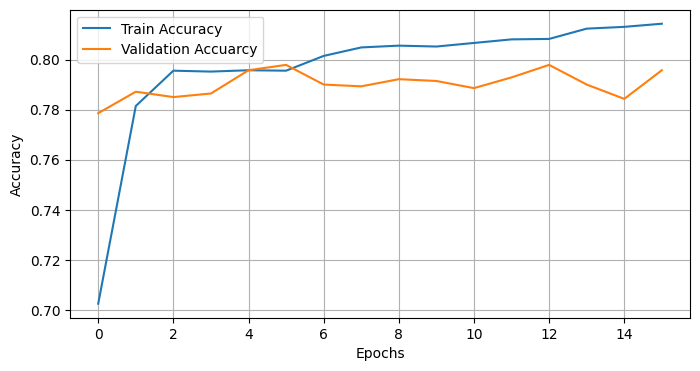

In [19]:
plt.figure(figsize=(8,4))
plt.plot(history_best_hyperbadnd.history['class_output_accuracy'], label='Train Accuracy')
plt.plot(history_best_hyperbadnd.history['val_class_output_accuracy'], label='Validation Accuarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[0.42912248 0.94115095 0.27026848 0.15653537 0.38133398 0.56841484
 0.56597461 0.55577606 0.84560249 0.573536  ]


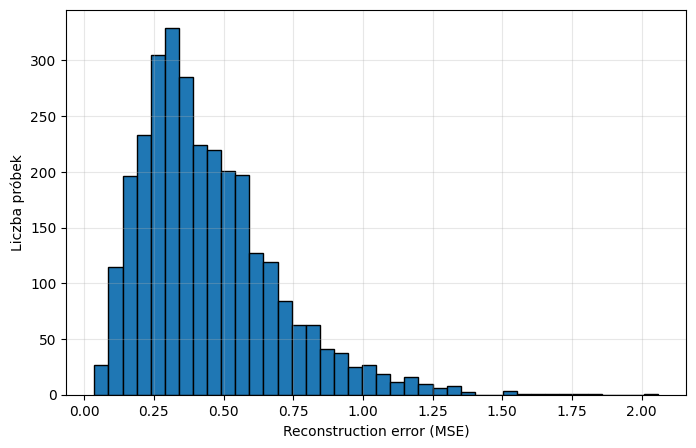

In [20]:
# Predykcja rekonstrukcji (wyjście drugie)
class_pred, x_test_pred = best_model_hyperband.predict(x_test_scaled)

# Błąd rekonstrukcji MSE dla każdej próbki
recon_errors_hyperband = np.mean((x_test_scaled - x_test_pred)**2, axis=1)
print(recon_errors_hyperband[:10])

plt.figure(figsize=(8,5))
plt.hist(recon_errors_hyperband, bins=40, edgecolor='black')
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Liczba próbek")
plt.grid(True, alpha=0.3)
plt.show()


## Optuna pruning

In [22]:
input_dim = x_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

def build_autoencoder(units_1, units_2, encoding_dim, class_units, learning_rate):
    # WEJSCIE
    inp = layers.Input(shape=(input_dim,))

    # ENCODER
    x = layers.Dense(units_1, activation='relu')(inp)
    x = layers.Dense(units_2, activation='relu')(x)
    bottleneck = layers.Dense(encoding_dim, activation='relu', name="bottleneck")(x)

    # DECODER
    d = layers.Dense(units_2, activation='relu')(bottleneck)
    d = layers.Dense(units_1, activation='relu')(d)
    reconstruction = layers.Dense(input_dim, activation='linear', name="reconstruction")(d)

    # KLASYFIKATOR
    c = layers.Dense(class_units, activation='relu')(bottleneck)
    class_out = layers.Dense(num_classes, activation='softmax', name="class_output")(c)

    model = keras.Model(inputs=inp, outputs=[class_out, reconstruction])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss={
            "class_output": "sparse_categorical_crossentropy",
            "reconstruction": "mse"
        },
        loss_weights={
            "class_output": 1.0,
            "reconstruction": 0.5
        },
        metrics={
            "class_output": SparseCategoricalAccuracy(name="accuracy")
        }
    )
    return model


def objective(trial):
    # HIPERPARAMETRY Optuny
    units_1 = trial.suggest_int("units_1", 16, 128, step=16)
    units_2 = trial.suggest_int("units_2", 8, 64, step=8)
    encoding_dim = trial.suggest_int("encoding_dim", 4, 12, step=2)
    class_units = trial.suggest_int("class_units", 8, 64, step=8)
    learning_rate = trial.suggest_categorical("learning_rate", [0.001, 0.003, 0.005, 0.01])

    model = build_autoencoder(units_1, units_2, encoding_dim, class_units, learning_rate)

    es = keras.callbacks.EarlyStopping(
        monitor="val_class_output_accuracy",
        patience=10,
        mode="max",
        restore_best_weights=True
    )

    pruning = TFKerasPruningCallback(
        trial,
        monitor="val_class_output_accuracy"
    )

    history = model.fit(
        x_train_scaled,
        {"class_output": y_train, "reconstruction": x_train_scaled},
        validation_data=(
            x_val_scaled,
            {"class_output": y_val, "reconstruction": x_val_scaled}
        ),
        epochs=50,
        batch_size=64,
        verbose=0,
        callbacks=[es, pruning]
    )

    return max(history.history["val_class_output_accuracy"])


start = time.perf_counter()
process = psutil.Process()

study = optuna.create_study(
    direction="maximize",
    study_name="supervised_autoencoder_optuna9"
)

study.optimize(objective, n_trials=20)

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024 * 1024)

print(f"\nCzas szukania: {elapsed:.2f} s")
print(f"Zużycie pamięci: {mem_used:.2f} MB\n")

print("Najlepsze hiperparametry:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

print("\nNajlepsze val accuracy:", study.best_value)

best_params = study.best_params

best_model_optuna_pruning = build_autoencoder(
    units_1=best_params["units_1"],
    units_2=best_params["units_2"],
    encoding_dim=best_params["encoding_dim"],
    class_units=best_params["class_units"],
    learning_rate=best_params["learning_rate"]
)

es_final = keras.callbacks.EarlyStopping(
    monitor="val_class_output_accuracy",
    patience=10,
    mode="max",
    restore_best_weights=True
)

history_final_optuna_pruning = best_model_optuna_pruning.fit(
    x_train_scaled,
    {"class_output": y_train, "reconstruction": x_train_scaled},
    validation_data=(
        x_val_scaled,
        {"class_output": y_val, "reconstruction": x_val_scaled}
    ),
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[es_final]
)

# EWALUACJA na zbiorze testowym
results_optuna_pruning = best_model_optuna_pruning.evaluate(
    x_test_scaled,
    {"class_output": y_test, "reconstruction": x_test_scaled},
    return_dict=True
)

print("\nWyniki na zbiorze testowym:")
for k, v in results_optuna_pruning.items():
    print(f"{k}: {v:.4f}")


[I 2026-01-20 01:14:46,165] A new study created in memory with name: supervised_autoencoder_optuna9
[I 2026-01-20 01:14:53,794] Trial 0 finished with value: 0.7992857098579407 and parameters: {'units_1': 32, 'units_2': 8, 'encoding_dim': 8, 'class_units': 24, 'learning_rate': 0.001}. Best is trial 0 with value: 0.7992857098579407.
[I 2026-01-20 01:15:02,775] Trial 1 finished with value: 0.7950000166893005 and parameters: {'units_1': 64, 'units_2': 48, 'encoding_dim': 12, 'class_units': 32, 'learning_rate': 0.001}. Best is trial 0 with value: 0.7992857098579407.
[I 2026-01-20 01:15:10,885] Trial 2 finished with value: 0.7950000166893005 and parameters: {'units_1': 80, 'units_2': 24, 'encoding_dim': 4, 'class_units': 48, 'learning_rate': 0.003}. Best is trial 0 with value: 0.7992857098579407.
[I 2026-01-20 01:15:16,254] Trial 3 finished with value: 0.7978571653366089 and parameters: {'units_1': 112, 'units_2': 40, 'encoding_dim': 4, 'class_units': 48, 'learning_rate': 0.001}. Best is tri


Czas szukania: 106.48 s
Zużycie pamięci: 3608.07 MB

Najlepsze hiperparametry:
units_1: 16
units_2: 16
encoding_dim: 12
class_units: 8
learning_rate: 0.01

Najlepsze val accuracy: 0.8064285516738892
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - class_output_accuracy: 0.7011 - class_output_loss: 0.6476 - loss: 1.0362 - reconstruction_loss: 0.7746 - val_class_output_accuracy: 0.7907 - val_class_output_loss: 0.4884 - val_loss: 0.8200 - val_reconstruction_loss: 0.6635
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - class_output_accuracy: 0.7932 - class_output_loss: 0.4757 - loss: 0.7872 - reconstruction_loss: 0.6236 - val_class_output_accuracy: 0.7871 - val_class_output_loss: 0.4846 - val_loss: 0.7700 - val_reconstruction_loss: 0.5714
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - class_output_accuracy: 0.7937 - class_output_loss: 0.4712 - loss: 0.7408 - reconstruction_loss: 0.5388 - val_class_output_accuracy: 0.7957 - val_class_output_loss: 0.4686 - val_loss: 0.7260 - val_

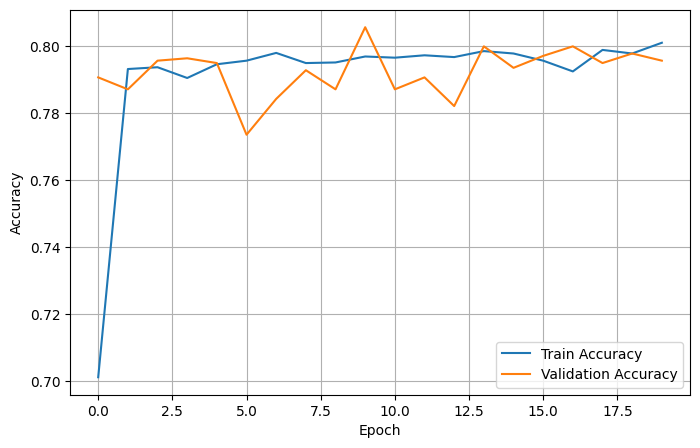

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history_final_optuna_pruning.history["class_output_accuracy"],label ='Train Accuracy')
plt.plot(history_final_optuna_pruning.history["val_class_output_accuracy"], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step
[0.45462838 0.84042767 0.20654216 0.20570438 0.24959175 0.58275766
 0.28920712 0.42227204 0.57774132 0.45681257]


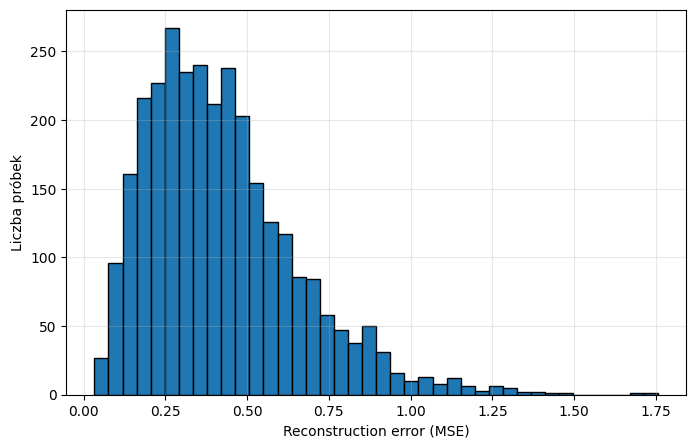

In [26]:
# Predykcja rekonstrukcji (wyjście drugie) z najlepszego modelu Optuny
class_pred_optuna, x_test_pred_optuna = best_model_optuna_pruning.predict(x_test_scaled)

# Błąd rekonstrukcji MSE dla każdej próbki
recon_errors_optuna_pruning = np.mean((x_test_scaled - x_test_pred_optuna) ** 2, axis=1)
print(recon_errors_optuna_pruning[:10])

plt.figure(figsize=(8, 5))
plt.hist(recon_errors_optuna_pruning, bins=40, edgecolor='black')
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Liczba próbek")
plt.grid(True, alpha=0.3)
plt.show()


## Optuna bez pruning

In [27]:
input_dim = x_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

# FUNKCJA BUDUJĄCA MODEL (czysta)
def build_autoencoder(units_1, units_2, encoding_dim, class_units, learning_rate):

    inp = layers.Input(shape=(input_dim,))

    # ENCODER
    x = layers.Dense(units_1, activation='relu')(inp)
    x = layers.Dense(units_2, activation='relu')(x)
    bottleneck = layers.Dense(encoding_dim, activation='relu', name="bottleneck")(x)

    # DECODER
    d = layers.Dense(units_2, activation='relu')(bottleneck)
    d = layers.Dense(units_1, activation='relu')(d)
    reconstruction = layers.Dense(input_dim, activation='linear', name="reconstruction")(d)

    # KLASYFIKATOR
    c = layers.Dense(class_units, activation='relu')(bottleneck)
    class_out = layers.Dense(num_classes, activation='softmax', name="class_output")(c)

    # MODEL
    model = keras.Model(inputs=inp, outputs=[class_out, reconstruction])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss={
            "class_output": "sparse_categorical_crossentropy",
            "reconstruction": "mse"
        },
        loss_weights={
            "class_output": 1.0,
            "reconstruction": 0.5
        },
        metrics={
            "class_output": SparseCategoricalAccuracy(name="accuracy")
        }
    )

    return model


# FUNKCJA CELU DO OPTUNY (BEZ PRUNINGU)
def objective(trial):
    units_1 = trial.suggest_int("units_1", 16, 128, step=16)
    units_2 = trial.suggest_int("units_2", 8, 64, step=8)
    encoding_dim = trial.suggest_int("encoding_dim", 4, 12, step=2)
    class_units = trial.suggest_int("class_units", 8, 64, step=8)
    learning_rate = trial.suggest_categorical("learning_rate", [0.001, 0.003, 0.005, 0.01])

    model = build_autoencoder(units_1, units_2, encoding_dim, class_units, learning_rate)

    es = keras.callbacks.EarlyStopping(
        monitor="val_class_output_accuracy",
        patience=10,
        mode="max",
        restore_best_weights=True
    )

    # TRENING (walidacja na zbiorze walidacyjnym, nie testowym)
    history = model.fit(
        x_train_scaled,
        {"class_output": y_train, "reconstruction": x_train_scaled},
        validation_data=(
            x_val_scaled,
            {"class_output": y_val, "reconstruction": x_val_scaled}
        ),
        epochs=50,
        batch_size=64,
        verbose=0,
        callbacks=[es]
    )

    return max(history.history["val_class_output_accuracy"])


start = time.perf_counter()
process = psutil.Process()

study = optuna.create_study(
    direction="maximize",
    study_name="supervised_autoencoder_optuna_bez4"
)

study.optimize(objective, n_trials=20)

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024 * 1024)

print(f"\nCzas szukania: {elapsed:.2f} s")
print(f"Zużycie pamięci: {mem_used:.2f} MB\n")

print("Najlepsze hiperparametry:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

print("\nNajlepsze val accuracy:", study.best_value)

best_params = study.best_params

best_model_optuna_bez = build_autoencoder(
    units_1=best_params["units_1"],
    units_2=best_params["units_2"],
    encoding_dim=best_params["encoding_dim"],
    class_units=best_params["class_units"],
    learning_rate=best_params["learning_rate"]
)

es_final = keras.callbacks.EarlyStopping(
    monitor="val_class_output_accuracy",
    patience=10,
    mode="max",
    restore_best_weights=True
)

history_final_optuna_bez_purning = best_model_optuna_bez.fit(
    x_train_scaled,
    {"class_output": y_train, "reconstruction": x_train_scaled},
    validation_data=(
        x_val_scaled,
        {"class_output": y_val, "reconstruction": x_val_scaled}
    ),
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[es_final]
)

# EWALUACJA na zbiorze testowym (tylko na końcu)
results_optuna_bez_purning = best_model_optuna_bez.evaluate(
    x_test_scaled,
    {"class_output": y_test, "reconstruction": x_test_scaled},
    return_dict=True
)

print("\nWyniki na zbiorze testowym:")
for k, v in results_optuna_bez_purning.items():
    print(f"{k}: {v:.4f}")


[I 2026-01-20 01:20:01,546] A new study created in memory with name: supervised_autoencoder_optuna_bez4
[I 2026-01-20 01:20:07,193] Trial 0 finished with value: 0.7992857098579407 and parameters: {'units_1': 16, 'units_2': 16, 'encoding_dim': 8, 'class_units': 40, 'learning_rate': 0.001}. Best is trial 0 with value: 0.7992857098579407.
[I 2026-01-20 01:20:12,198] Trial 1 finished with value: 0.8007143139839172 and parameters: {'units_1': 64, 'units_2': 16, 'encoding_dim': 8, 'class_units': 8, 'learning_rate': 0.001}. Best is trial 1 with value: 0.8007143139839172.
[I 2026-01-20 01:20:18,981] Trial 2 finished with value: 0.8014285564422607 and parameters: {'units_1': 96, 'units_2': 48, 'encoding_dim': 4, 'class_units': 16, 'learning_rate': 0.001}. Best is trial 2 with value: 0.8014285564422607.
[I 2026-01-20 01:20:25,282] Trial 3 finished with value: 0.8042857050895691 and parameters: {'units_1': 80, 'units_2': 40, 'encoding_dim': 10, 'class_units': 64, 'learning_rate': 0.005}. Best is 


Czas szukania: 135.70 s
Zużycie pamięci: 3856.45 MB

Najlepsze hiperparametry:
units_1: 80
units_2: 40
encoding_dim: 10
class_units: 64
learning_rate: 0.005

Najlepsze val accuracy: 0.8042857050895691
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - class_output_accuracy: 0.7596 - class_output_loss: 0.5510 - loss: 0.8462 - reconstruction_loss: 0.5874 - val_class_output_accuracy: 0.7779 - val_class_output_loss: 0.4896 - val_loss: 0.6817 - val_reconstruction_loss: 0.3847
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - class_output_accuracy: 0.7887 - class_output_loss: 0.4686 - loss: 0.6394 - reconstruction_loss: 0.3434 - val_class_output_accuracy: 0.7850 - val_class_output_loss: 0.4898 - val_loss: 0.6470 - val_reconstruction_loss: 0.3152
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - class_output_accuracy: 0.7934 - class_output_loss: 0.4655 - loss: 0.6211 - reconstruction_loss: 0.3111 - val_class_output_accuracy: 0.8000 - val_class_output_loss: 0.4678 - val_loss: 0.6227 - va

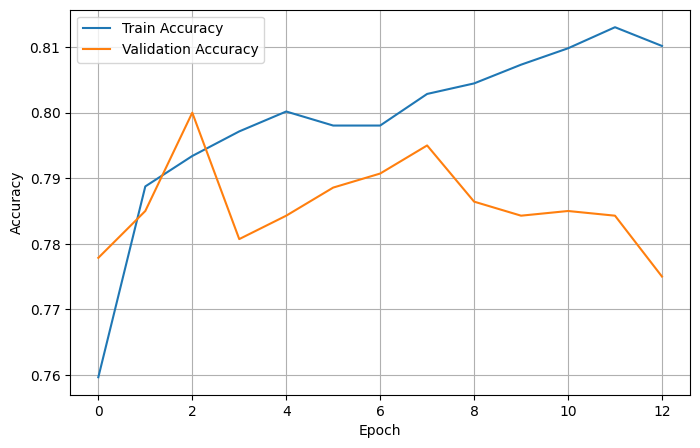

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history_final_optuna_bez_purning.history['class_output_accuracy'], label='Train Accuracy')
plt.plot(history_final_optuna_bez_purning.history['val_class_output_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[0.3350585  0.20017084 0.06793113 0.2073265  0.25185048 0.43972264
 0.319122   0.23851736 0.51649854 0.32018037]


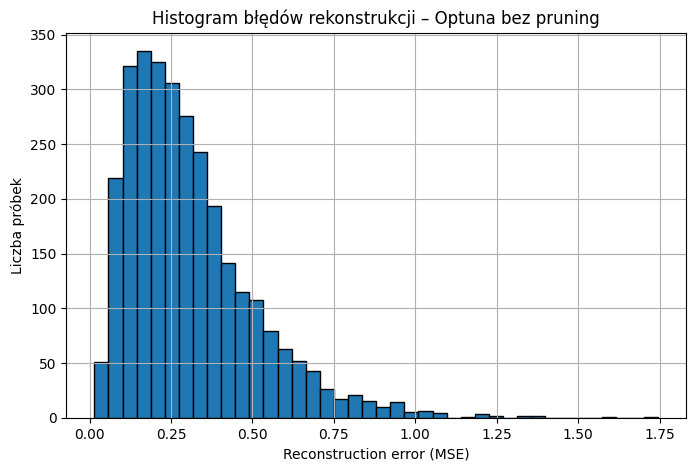

In [30]:
# Predykcja rekonstrukcji (wyjście drugie) z najlepszego modelu Optuny
class_pred_optuna, x_test_pred_optuna = best_model_optuna_bez.predict(x_test_scaled)

# Błąd rekonstrukcji MSE dla każdej próbki
recon_errors_optuna_bez = np.mean((x_test_scaled - x_test_pred_optuna) ** 2, axis=1)
print(recon_errors_optuna_bez[:10])

plt.figure(figsize=(8, 5))
plt.hist(recon_errors_optuna_bez, bins=40, edgecolor='black')
plt.title("Histogram błędów rekonstrukcji – Optuna bez pruning")
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Liczba próbek")
plt.grid(True)
plt.show()


## Ray tune z ASHA

In [32]:
import time
import psutil
import numpy as np

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.metrics import SparseCategoricalAccuracy

from ray import tune
from ray.air import session
from ray.tune import Tuner
from ray.tune.tune_config import TuneConfig
from ray.tune.schedulers import ASHAScheduler

input_dim = x_train_scaled.shape[1]
num_classes = len(np.unique(y_train))


def build_classifier_model(config, input_dim, num_classes):
    units_1      = config["units_1"]
    units_2      = config["units_2"]
    encoding_dim = config["encoding_dim"]
    class_units  = config["class_units"]
    lr           = config["lr"]

    inputs = layers.Input(shape=(input_dim,))

    # encoder
    x = layers.Dense(units_1, activation="relu")(inputs)
    x = layers.Dense(units_2, activation="relu")(x)
    bottleneck = layers.Dense(encoding_dim, activation="relu", name="bottleneck")(x)

    # classifier
    c = layers.Dense(class_units, activation="relu")(bottleneck)
    class_out = layers.Dense(num_classes, activation="softmax", name="class_output")(c)

    model = keras.Model(inputs=inputs, outputs=class_out)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[SparseCategoricalAccuracy(name="accuracy")]
    )

    return model


def train_autoencoder_supervised_clf(config, x_train, y_train, x_val, y_val, epochs=50, batch_size=64):
    model = build_classifier_model(
        config,
        input_dim=x_train.shape[1],
        num_classes=len(np.unique(y_train))
    )

    es = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        mode="max",
        restore_best_weights=True
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[es]
    )

    best_val_acc = float(np.nanmax(history.history["val_accuracy"]))
    session.report({"val_accuracy": best_val_acc})


# Przestrzeń hiperparametrów
search_space = {
    "units_1": tune.choice([16, 32, 64, 128]),
    "units_2": tune.choice([8, 16, 32, 64]),
    "encoding_dim": tune.choice([4, 6, 8, 10, 12]),
    "class_units": tune.choice([8, 16, 32, 64]),
    "lr": tune.choice([0.001, 0.003, 0.005, 0.01]),
}

# Uruchomienie Tuner-a (z harmonogramem ASHA)
start = time.perf_counter()
process = psutil.Process()

scheduler = ASHAScheduler(
    max_t=50,
    grace_period=5,
    reduction_factor=3
)

tuner_ray = Tuner(
    tune.with_parameters(
        train_autoencoder_supervised_clf,
        x_train=x_train_scaled,
        y_train=y_train,
        x_val=x_val_scaled,
        y_val=y_val,
        epochs=50,
        batch_size=64,
    ),
    param_space=search_space,
    tune_config=TuneConfig(
        metric="val_accuracy",
        mode="max",
        num_samples=20,
        scheduler=scheduler,
    ),
)

results = tuner_ray.fit()

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024 * 1024)

best = results.get_best_result(metric="val_accuracy", mode="max")

print(f"\nCzas tuningu: {elapsed:.2f} s")
print(f"Zużycie pamięci: {mem_used:.2f} MB")
print("Najlepszy config:", best.config)
print("Najlepsza val_accuracy:", best.metrics["val_accuracy"])


def build_autoencoder(config, input_dim, num_classes):
    units_1 = config["units_1"]
    units_2 = config["units_2"]
    encoding_dim = config["encoding_dim"]
    class_units = config["class_units"]
    lr = config["lr"]

    inp = layers.Input(shape=(input_dim,))

    # ENCODER
    x = layers.Dense(units_1, activation="relu")(inp)
    x = layers.Dense(units_2, activation="relu")(x)
    bottleneck = layers.Dense(encoding_dim, activation="relu", name="bottleneck")(x)

    # DECODER
    d = layers.Dense(units_2, activation="relu")(bottleneck)
    d = layers.Dense(units_1, activation="relu")(d)
    reconstruction = layers.Dense(
        input_dim,
        activation="linear",
        name="reconstruction"
    )(d)

    # KLASYFIKATOR
    c = layers.Dense(class_units, activation="relu")(bottleneck)
    class_out = layers.Dense(
        num_classes,
        activation="softmax",
        name="class_output"
    )(c)

    model = keras.Model(inputs=inp, outputs=[class_out, reconstruction])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss={
            "class_output": "sparse_categorical_crossentropy",
            "reconstruction": "mse"
        },
        loss_weights={
            "class_output": 1.0,
            "reconstruction": 0.5
        },
        metrics={
            "class_output": SparseCategoricalAccuracy(name="accuracy")
        }
    )

    return model


# Trening finalnego modelu (clf + rekonstrukcja)
best_model_ray = build_autoencoder(
    best.config,
    input_dim=x_train_scaled.shape[1],
    num_classes=num_classes
)

history_best_ray = best_model_ray.fit(
    x_train_scaled,
    {"class_output": y_train, "reconstruction": x_train_scaled},
    validation_data=(
        x_val_scaled,
        {"class_output": y_val, "reconstruction": x_val_scaled}
    ),
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_class_output_accuracy",
            patience=10,
            mode="max",
            restore_best_weights=True
        )
    ]
)

eval_results = best_model_ray.evaluate(
    x_test_scaled,
    {"class_output": y_test, "reconstruction": x_test_scaled},
    return_dict=True
)

print("\nWyniki na zbiorze testowym (pełny autoenkoder):")
for k, v in eval_results.items():
    print(f"{k}: {v:.4f}")


2026-01-20 01:28:24,339	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\ASUSZE~1\AppData\Local\Temp\ray\session_2026-01-20_01-27-11_409097_36000\artifacts\2026-01-20_01-28-24\train_autoencoder_supervised_clf_2026-01-20_01-28-24\driver_artifacts\train_autoencoder_supervised_clf_ee737_00000_0_class_units=64,encoding_dim=12,lr=0.0030,units_1=32,units_2=64_2026-01-20_01-28-24
2026-01-20 01:28:24,342	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\ASUSZE~1\AppData\Local\Temp\ray\session_2026-01-20_01-27-11_409097_36000\artifacts\2026-01-20_01-28-24\train_autoencoder_supervised_clf_2026-01-20_01-28-24\driver_artifacts\train_autoencoder_supervised_clf_ee737_00000_0_class_units=64,encoding_dim=12,lr=0.0030,units_1=32,units_2=64_2026-01-20_01-28-24
2026-01-20 01:28


Czas tuningu: 86.23 s
Zużycie pamięci: 3439.10 MB
Najlepszy config: {'units_1': 64, 'units_2': 8, 'encoding_dim': 10, 'class_units': 64, 'lr': 0.01}
Najlepsza val_accuracy: 0.8050000071525574
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - class_output_accuracy: 0.7354 - class_output_loss: 0.5588 - loss: 0.9226 - reconstruction_loss: 0.7243 - val_class_output_accuracy: 0.7721 - val_class_output_loss: 0.5128 - val_loss: 0.8331 - val_reconstruction_loss: 0.6405
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - class_output_accuracy: 0.7837 - class_output_loss: 0.4800 - loss: 0.7749 - reconstruction_loss: 0.5898 - val_class_output_accuracy: 0.7971 - val_class_output_loss: 0.4764 - val_loss: 0.7579 - val_reconstruction_loss: 0.5634
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - class_output_accuracy: 0.7832 - class_output_loss: 0.4706 - loss: 0.7475 - reconstruction_loss: 0.5528 - val_class_output_accuracy: 0.7957 - val_class_output_loss: 0.4705 - val_loss: 0.7380 - val_reconst

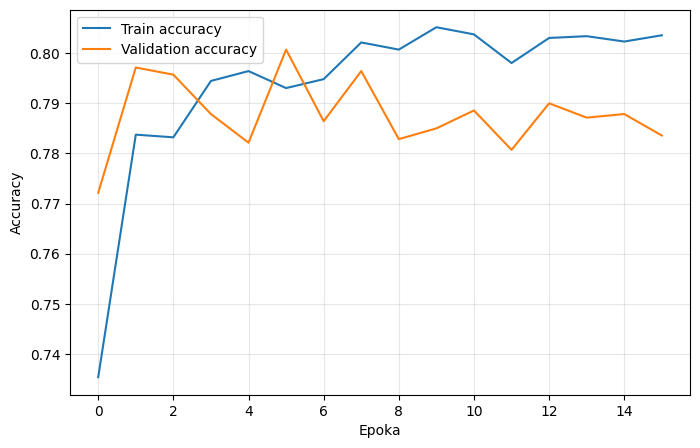

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


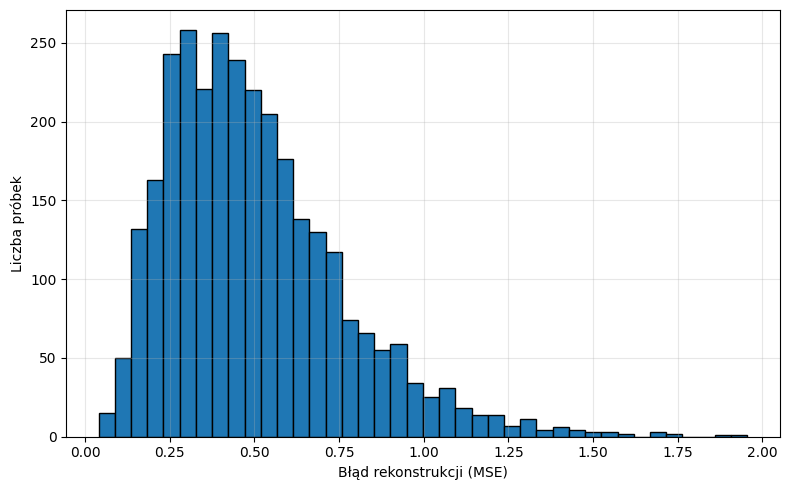

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(history_best_ray.history["class_output_accuracy"], label="Train accuracy")
plt.plot(history_best_ray.history["val_class_output_accuracy"], label="Validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

class_pred, x_test_recon = best_model_ray.predict(x_test_scaled)
recon_errors_ray_pruning = np.mean((x_test_scaled - x_test_recon) ** 2, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(recon_errors, bins=40, edgecolor="black")
plt.xlabel("Błąd rekonstrukcji (MSE)")
plt.ylabel("Liczba próbek")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Ray Tune bez ASHA

In [34]:
import time
import psutil
import numpy as np

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.metrics import SparseCategoricalAccuracy

from ray import tune
from ray.air import session
from ray.tune import Tuner
from ray.tune.tune_config import TuneConfig

input_dim = x_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

def build_classifier_model(config, input_dim, num_classes):
    units_1 = config["units_1"]
    units_2 = config["units_2"]
    encoding_dim = config["encoding_dim"]
    class_units = config["class_units"]
    lr = config["lr"]

    inputs = layers.Input(shape=(input_dim,))

    # encoder
    x = layers.Dense(units_1, activation="relu")(inputs)
    x = layers.Dense(units_2, activation="relu")(x)
    bottleneck = layers.Dense(encoding_dim, activation="relu", name="bottleneck")(x)

    # klasyfikator
    c = layers.Dense(class_units, activation="relu")(bottleneck)
    class_out = layers.Dense(num_classes, activation="softmax", name="class_output")(c)

    model = keras.Model(inputs=inputs, outputs=class_out)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[SparseCategoricalAccuracy(name="accuracy")]
    )

    return model


def train_autoencoder_supervised_clf(config, x_train, y_train, x_val, y_val, epochs=50, batch_size=64):
    model = build_classifier_model(
        config,
        input_dim=x_train.shape[1],
        num_classes=len(np.unique(y_train))
    )

    es = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        mode="max",
        restore_best_weights=True
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[es]
    )

    best_val_acc = float(np.nanmax(history.history["val_accuracy"]))
    session.report({"val_accuracy": best_val_acc})


# Przestrzeń hiperparametrów
search_space = {
    "units_1": tune.choice([16, 32, 64, 128]),
    "units_2": tune.choice([8, 16, 32, 64]),
    "encoding_dim": tune.choice([4, 6, 8, 10, 12]),
    "class_units": tune.choice([8, 16, 32, 64]),
    "lr": tune.choice([1e-3, 5e-4, 1e-4]),
}

start = time.perf_counter()
process = psutil.Process()

tuner_ray = Tuner(
    tune.with_parameters(
        train_autoencoder_supervised_clf,
        x_train=x_train_scaled,
        y_train=y_train,
        x_val=x_val_scaled,
        y_val=y_val,
        epochs=50,
        batch_size=64,
    ),
    param_space=search_space,
    tune_config=TuneConfig(
        metric="val_accuracy",
        mode="max",
        num_samples=20,
    ),
)

results = tuner_ray.fit()

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024 * 1024)

best = results.get_best_result(metric="val_accuracy", mode="max")

print(f"\nCzas tuningu: {elapsed:.2f} s")
print(f"Zużycie pamięci: {mem_used:.2f} MB")
print("Najlepszy config:", best.config)
print("Najlepsza val_accuracy:", best.metrics["val_accuracy"])


def build_full_supervised_autoencoder(config, input_dim, num_classes):
    units_1 = config["units_1"]
    units_2 = config["units_2"]
    encoding_dim = config["encoding_dim"]
    class_units = config["class_units"]
    lr = config["lr"]

    inp = layers.Input(shape=(input_dim,))

    # ENCODER
    x = layers.Dense(units_1, activation="relu")(inp)
    x = layers.Dense(units_2, activation="relu")(x)
    bottleneck = layers.Dense(encoding_dim, activation="relu", name="bottleneck")(x)

    # DECODER
    d = layers.Dense(units_2, activation="relu")(bottleneck)
    d = layers.Dense(units_1, activation="relu")(d)
    reconstruction = layers.Dense(
        input_dim,
        activation="linear",
        name="reconstruction"
    )(d)

    # KLASYFIKATOR
    c = layers.Dense(class_units, activation="relu")(bottleneck)
    class_out = layers.Dense(
        num_classes,
        activation="softmax",
        name="class_output"
    )(c)

    model = keras.Model(inputs=inp, outputs=[class_out, reconstruction])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss={
            "class_output": "sparse_categorical_crossentropy",
            "reconstruction": "mse"
        },
        loss_weights={
            "class_output": 1.0,
            "reconstruction": 0.5
        },
        metrics={
            "class_output": SparseCategoricalAccuracy(name="accuracy")
        }
    )

    return model


best_model_ray_no_pruning = build_full_supervised_autoencoder(
    best.config,
    input_dim=x_train_scaled.shape[1],
    num_classes=num_classes
)

history_best_ray_no = best_model_ray_no_pruning.fit(
    x_train_scaled,
    {"class_output": y_train, "reconstruction": x_train_scaled},
    validation_data=(
        x_val_scaled,
        {"class_output": y_val, "reconstruction": x_val_scaled}
    ),
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_class_output_accuracy",
            patience=10,
            mode="max",
            restore_best_weights=True
        )
    ]
)

eval_results_ray_no = best_model_ray_no_pruning.evaluate(
    x_test_scaled,
    {"class_output": y_test, "reconstruction": x_test_scaled},
    return_dict=True
)

print("\nWyniki na zbiorze testowym (pełny autoenkoder):")
for k, v in eval_results_ray_no.items():
    print(f"{k}: {v:.4f}")


2026-01-20 01:39:54,967	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\ASUSZE~1\AppData\Local\Temp\ray\session_2026-01-20_01-27-11_409097_36000\artifacts\2026-01-20_01-39-54\train_autoencoder_supervised_clf_2026-01-20_01-39-54\driver_artifacts\train_autoencoder_supervised_clf_8a166_00000_0_class_units=8,encoding_dim=6,lr=0.0001,units_1=64,units_2=16_2026-01-20_01-39-54
2026-01-20 01:39:54,976	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\ASUSZE~1\AppData\Local\Temp\ray\session_2026-01-20_01-27-11_409097_36000\artifacts\2026-01-20_01-39-54\train_autoencoder_supervised_clf_2026-01-20_01-39-54\driver_artifacts\train_autoencoder_supervised_clf_8a166_00000_0_class_units=8,encoding_dim=6,lr=0.0001,units_1=64,units_2=16_2026-01-20_01-39-54
2026-01-20 01:39:54,


Czas tuningu: 112.60 s
Zużycie pamięci: 3041.63 MB
Najlepszy config: {'units_1': 16, 'units_2': 64, 'encoding_dim': 12, 'class_units': 8, 'lr': 0.0005}
Najlepsza val_accuracy: 0.8050000071525574
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - class_output_accuracy: 0.4729 - class_output_loss: 0.9976 - loss: 1.4746 - reconstruction_loss: 0.9520 - val_class_output_accuracy: 0.6043 - val_class_output_loss: 0.9158 - val_loss: 1.3542 - val_reconstruction_loss: 0.8768
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - class_output_accuracy: 0.6964 - class_output_loss: 0.8136 - loss: 1.2159 - reconstruction_loss: 0.8035 - val_class_output_accuracy: 0.7579 - val_class_output_loss: 0.7018 - val_loss: 1.0628 - val_reconstruction_loss: 0.7224
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - class_output_accuracy: 0.7704 - class_output_loss: 0.5821 - loss: 0.9112 - reconstruction_loss: 0.6573 - val_class_output_accuracy: 0.7814 - val_class_output_loss: 0.5186 - val_loss: 0.8167 - val_reco

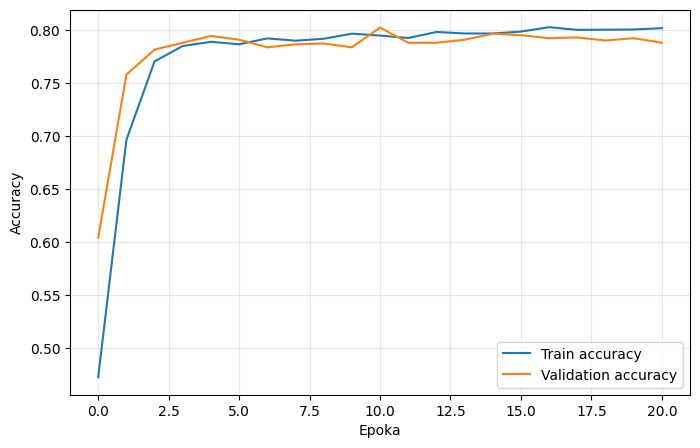

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


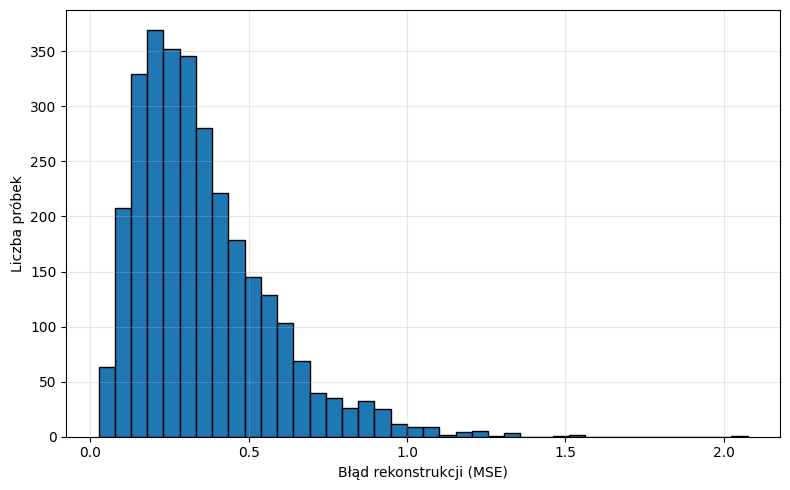

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history_best_ray_no.history["class_output_accuracy"], label="Train accuracy")
plt.plot(history_best_ray_no.history["val_class_output_accuracy"], label="Validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

class_pred, x_test_recon = best_model_ray_no_pruning.predict(x_test_scaled)
recon_errors_ray_no = np.mean((x_test_scaled - x_test_recon) ** 2, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(recon_errors_ray_no, bins=40, edgecolor="black")
plt.xlabel("Błąd rekonstrukcji (MSE)")
plt.ylabel("Liczba próbek")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


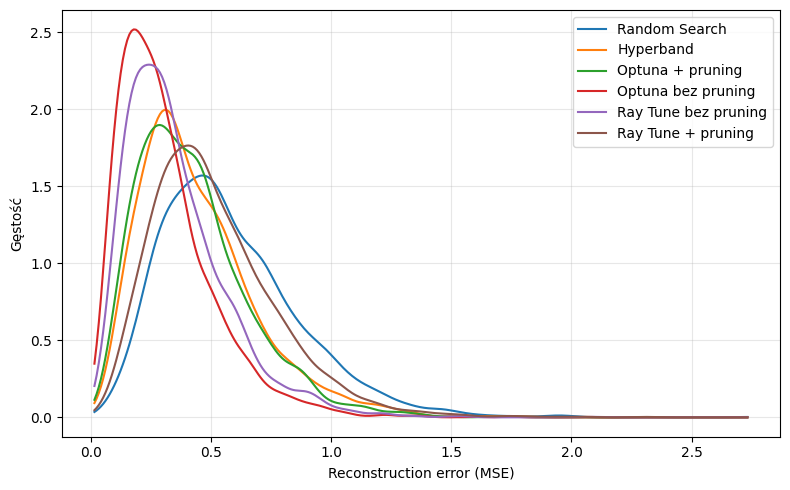

In [36]:
from scipy.stats import gaussian_kde

all_errors = np.concatenate([
    recon_errors_rs,
    recon_errors_hyperband,
    recon_errors_optuna_pruning,
    recon_errors_optuna_bez,
    recon_errors_ray_no,
    recon_errors_ray_pruning
])

x_grid = np.linspace(all_errors.min(), all_errors.max(), 300)

plt.figure(figsize=(8, 5))

for errors, label in [
    (recon_errors_rs,             "Random Search"),
    (recon_errors_hyperband,      "Hyperband"),
    (recon_errors_optuna_pruning, "Optuna + pruning"),
    (recon_errors_optuna_bez,     "Optuna bez pruning"),
    (recon_errors_ray_no,         "Ray Tune bez pruning"),
    (recon_errors_ray_pruning,    "Ray Tune + pruning"),
]:
    kde = gaussian_kde(errors)
    plt.plot(x_grid, kde(x_grid), label=label)

plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Gęstość")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
